# 03: The Utilisation Gap

**Business question**: Malaysia's grid operator has itself disclosed the gap between committed data centre capacity and actual electricity draw. How large is that gap, is it closing, and does a newly-surfaced government policy change how it should be read?

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
pipeline = pd.read_sql_query("SELECT * FROM tnb_dc_pipeline", conn)
conn.close()
pipeline['pct_of_secured'] = (pipeline['utilised_gw'] / pipeline['secured_gw'] * 100).round(1)
pipeline['pct_of_connected'] = (pipeline['utilised_gw'] / pipeline['connected_gw'] * 100).round(1)
pipeline

,quarter,secured_projects,secured_gw,connected_projects,connected_gw,utilised_gw,note,pct_of_secured,pct_of_connected
0,1Q FY2026,59,8.30,36,4.50,1.05,"Utilisation +117% YoY, +24% QoQ vs 4Q FY2025",12.7,23.3
1,2Q FY2026,61,8.35,42,5.65,1.26,16 projects/2.21GW under construction; 3 proje...,15.1,22.3


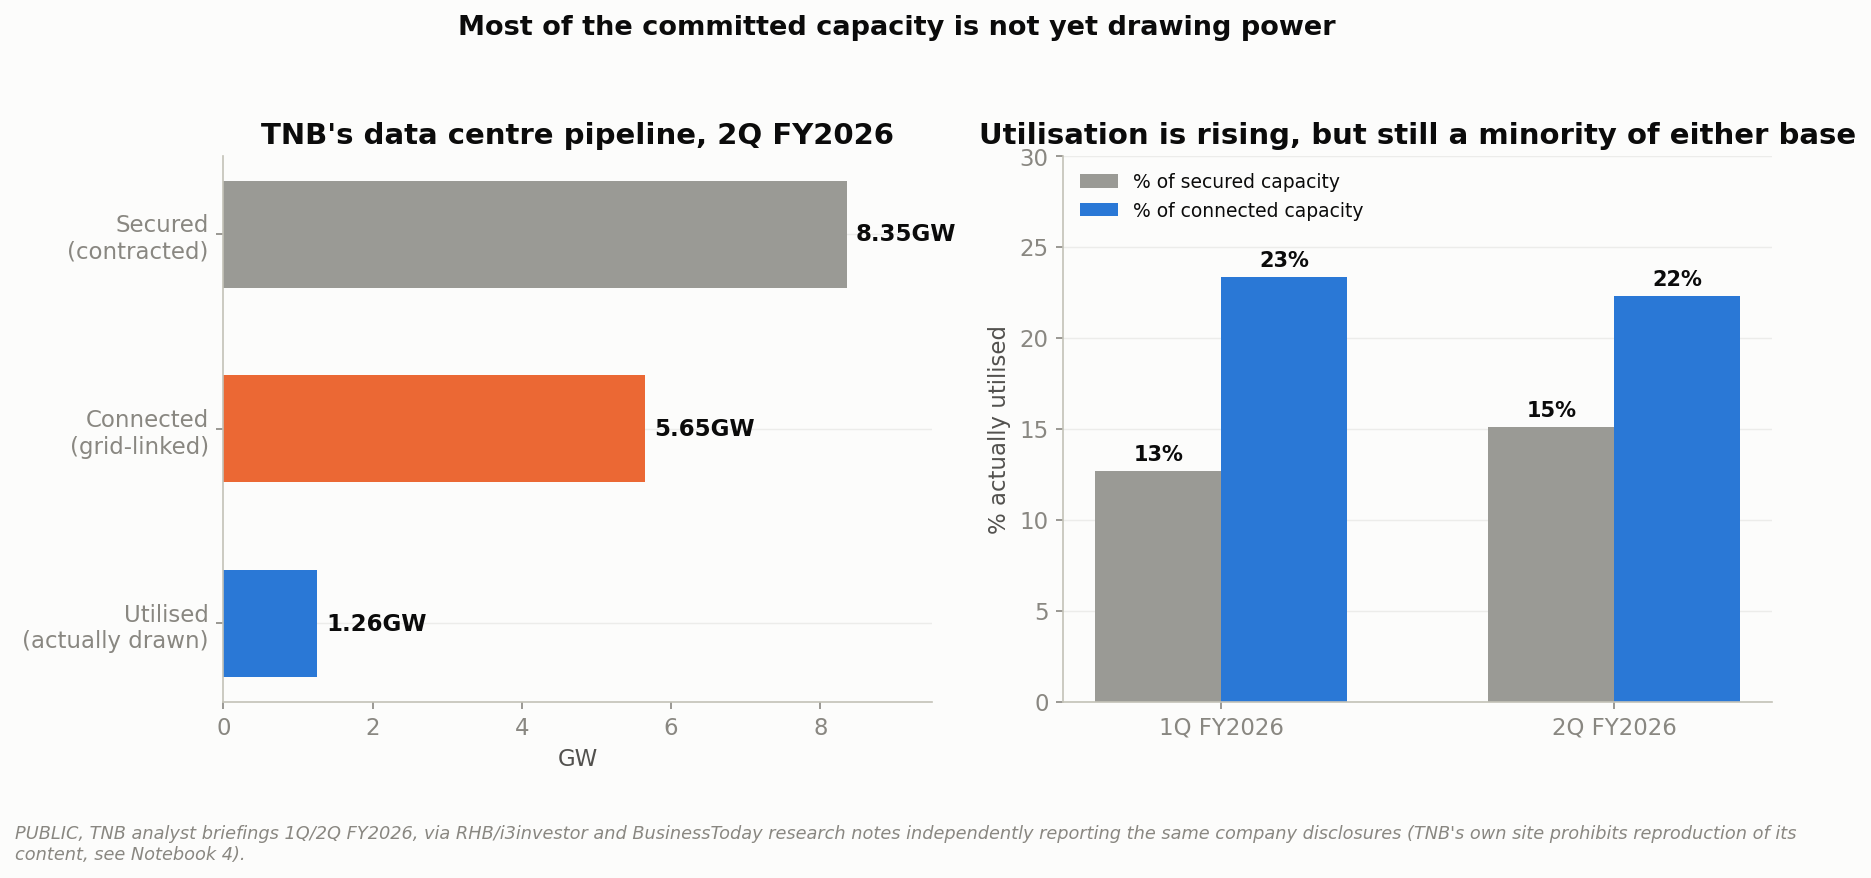

In [2]:
from IPython.display import Image
Image(filename='../outputs/figures/03_utilisation_gap.png')

## The headline gap, and why it needs two denominators, not one

By the second quarter of its 2026 financial year, Tenaga Nasional Berhad (TNB), Malaysia's grid monopoly, had signed Electricity Supply Agreements with **61 data centre projects, representing 8.35GW** of maximum contracted demand. Of those, **42 projects were actually grid-connected, representing 5.65GW**. Actual load utilisation across the connected projects was **1.26GW**. **[PUBLIC, TNB 2Q FY2026 analyst briefing, independently reported via BusinessToday and a moomoo republish of the same disclosure, since TNB's own site prohibits reproduction of its content, see Notebook 4]**

That 1.26GW is **15.1% of the 8.35GW secured** but **22.3% of the 5.65GW already connected**, two genuinely different numbers that tell two different stories. Measured against everything that has been contracted, four-fifths of the pipeline is not yet drawing meaningful power. Measured only against what's actually built and connected, the figure is less extreme, a bit under a quarter, closer to what might be expected for facilities in an early fit-out and ramp-up phase rather than facilities sitting idle after completion. Neither number is "the" right one; both are presented here rather than picking whichever tells a cleaner story.

One quarter earlier (1Q FY2026), the same two ratios were 12.6% of secured and 23.3% of connected, meaning utilisation as a share of secured capacity rose, while utilisation as a share of connected capacity actually fell slightly, because connected capacity grew faster that quarter than the load drawing on it. Both patterns are real and worth holding together: the funnel is filling in, but each new wave of newly-connected capacity temporarily dilutes the utilisation ratio before it ramps up.

## A complication that changes how "committed capacity" should be read

On 24 February 2026, Prime Minister Anwar Ibrahim told the Dewan Rakyat (Malaysia's parliament) that the government has, for roughly the past one and a half to two years, **quietly stopped approving new data centre applications not related to AI or high-tech use cases**, while continuing to approve AI-linked projects. His own words: *"For the past one and a half years, almost two years ago, we have limited the entry of new data centres that are not related to AI... all new applications that are not related [to AI/high-tech] have already been stopped."* **[PUBLIC, reported consistently by The Edge Malaysia, Malay Mail, and The Vibes, all covering the same 24 February 2026 parliamentary session]**

This was never announced as a formal policy before that parliamentary answer, and it matters for how this notebook's numbers should be read. The 8.35GW secured figure is not evidence of an unmanaged, runaway pipeline; it is what remains after roughly two years of the government itself filtering out non-AI applications. The utilisation gap is real, but it exists inside a pipeline that has already been curated, not an open floodgate. Anwar separately stated that power and water supply are sufficient for the next one to two years, a claim this project cannot independently verify but records as the government's own stated position.

## Explain It Simply

Think of TNB's data centre pipeline like a restaurant that has taken 61 reservations for a total of 8.35 "tables" worth of capacity. So far, 42 of those tables are actually built and wired up (5.65 tables' worth), but only about a quarter of that built capacity currently has diners actually eating (1.26 tables' worth of real electricity use). That's not necessarily alarming on its own, new restaurants fill up gradually, but it does mean the big "8.35GW committed" headline number overstates how much real activity is happening today. A separate, previously unannounced fact makes this less worrying than it might sound: the government has quietly been turning away new non-AI data centre bookings for about two years already, so this isn't an unfiltered wave of speculative reservations, it's what's left after the restaurant already turned people away at the door.

## Glossary

- **Electricity Supply Agreement (ESA)**: a contract between TNB and a customer (here, a data centre operator) specifying the maximum electricity demand TNB agrees to supply.
- **Secured capacity**: the maximum demand contracted under a signed ESA, regardless of whether the facility is built yet.
- **Connected capacity**: secured capacity where the physical grid connection has actually been completed.
- **Utilised capacity**: the electricity actually being drawn, measured against either the secured or connected base.

## Why Is This Happening?

**Why would a data centre sign a supply agreement for far more power than it currently uses?** Data centres are typically contracted, built, and fitted with servers in phases, an operator secures enough power for the facility's eventual full design capacity up front (since renegotiating a grid connection later is slow and expensive, see Notebook 1's discussion of connection timelines), then fills that capacity with servers and customers gradually over months or years as demand materialises. A low utilisation-to-secured ratio is therefore a normal feature of a market still in its build-out phase, not necessarily evidence of speculative overcommitment, though it does mean the more dramatic "gigawatts committed" headlines describe future intent more than current reality. The government's own quiet filtering of new non-AI applications since roughly mid-2024 (see above) suggests policymakers already share this notebook's instinct to distinguish real, durable demand from speculative reservation.

---
**Sources**: TNB 1Q FY2026 and 2Q FY2026 analyst briefings, as independently reported by RHB/i3investor, BusinessToday, and a moomoo republish of the same company disclosures (TNB's own website terms prohibit reproduction of its content; see Notebook 4 for the full compliance note); The Edge Malaysia, Malay Mail, and The Vibes, all reporting Prime Minister Anwar Ibrahim's 24 February 2026 Dewan Rakyat statement on the informal data centre application moratorium. Pipeline and utilisation figures are **PUBLIC**, company-disclosed via independent press pickup; the percentage-of-secured and percentage-of-connected ratios are **DERIVED**, calculated by this project from those disclosed figures.